In [1]:
import numpy as np
import pandas as pd
import sqlalchemy as db
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from get_all_data import get_all_data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
engine = db.create_engine('sqlite:///../data/raw/data.db')
df = get_all_data(engine)

Searching for events

[+] US Federal Funds Rate
Skipped — next release on 2026-03-18 (not yet passed)

[+] US FOMC Statement
Skipped — next release on 2026-03-18 (not yet passed)

[+] US FOMC Press Conference
Skipped — next release on 2026-03-18 (not yet passed)

[+] US FOMC Economic Projections
Skipped — next release on 2026-03-18 (not yet passed)

[+] US Core CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI y/y
Skipped — next release on 2026-04-10 (not yet passed)

[+] US PPI m/m
Skipped — next release on 2026-03-18 (not yet passed)

[+] US Core PCE Price Index m/m
Skipped — next release on 2026-04-09 (not yet passed)

[+] US Non-Farm Employment Change
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Unemployment Rate
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Average Hourly Earnings m/m
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Advance GD

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2271 entries, 2007-03-29 to 2026-03-13
Columns: 167 entries, US Advance GDP q/q to US FOMC Statement
dtypes: float64(167)
memory usage: 2.9 MB


In [4]:
df.columns.tolist()

['US Advance GDP q/q',
 'US Average Hourly Earnings m/m',
 'US Building Permits',
 'US CPI m/m',
 'US CPI y/y',
 'US Core CPI m/m',
 'US Core PCE Price Index m/m',
 'US Core Retail Sales m/m',
 'US Existing Home Sales',
 'US Federal Funds Rate',
 'US Final GDP q/q',
 'US Housing Starts',
 'US ISM Manufacturing PMI',
 'US ISM Services PMI',
 'US New Home Sales',
 'US Non-Farm Employment Change',
 'US PPI m/m',
 'US Personal Income m/m',
 'US Personal Spending m/m',
 'US Prelim GDP q/q',
 'US Retail Sales m/m',
 'US Unemployment Rate',
 'FEDFUNDS',
 'DFF',
 'T10Y2Y',
 'T10Y3M',
 'GS10',
 'GS2',
 'BAMLH0A0HYM2',
 'BAMLC0A0CM',
 'NFCI',
 'UNRATE',
 'CPIAUCSL',
 'T5YIE',
 'T10YIE',
 'ICSA',
 'WALCL',
 'M2SL',
 'TEDRATE',
 'spy_open',
 'spy_high',
 'spy_low',
 'spy_close',
 'spy_volume',
 'spy_EMA_14',
 'spy_EMA_30',
 'spy_EMA_60',
 'spy_SMA_14',
 'spy_SMA_30',
 'spy_SMA_60',
 'spy_BB_upper',
 'spy_BB_middle',
 'spy_BB_lower',
 'spy_RSI_14',
 'spy_RSI_21',
 'spy_RSI_30',
 'spy_MACD',
 'spy_M

In [5]:
df.head()

,US Advance GDP q/q,US Average Hourly Earnings m/m,US Building Permits,US CPI m/m,US CPI y/y,US Core CPI m/m,US Core PCE Price Index m/m,US Core Retail Sales m/m,US Existing Home Sales,US Federal Funds Rate,...,gc=f_MACD_signal,gc=f_MACD_hist,gc=f_AROON_down,gc=f_AROON_up,gc=f_MFI,gc=f_AVGPRICE,gc=f_MEDPRICE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement
date,,,,,,,,,,,,,,,,,,,,,
2007-03-29,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,0.895778,1.175966,21.428571,92.857143,21.635926,662.050003,660.399994,1490.0,1490.0,41.0
2007-03-30,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.161384,1.062423,14.285714,100.000000,28.540917,662.750000,663.399994,1489.0,1489.0,40.0
2007-04-02,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.435704,1.097282,7.142857,92.857143,27.775431,663.199997,660.799988,1486.0,1486.0,37.0
2007-04-04,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.994182,1.293880,0.000000,100.000000,30.387048,668.774994,669.500000,1484.0,1484.0,35.0
2007-04-13,0.035,0.003,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,4.358484,1.789605,28.571429,100.000000,30.706577,682.350006,681.899994,1475.0,1475.0,26.0


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [8]:
def make_prior_from_durations(durations_days: list[float], n_states: int, alpha_off: float = 1.0) -> np.ndarray:

    prior = np.full((n_states, n_states), alpha_off)
    for i, duration in enumerate(durations_days):
        # p_ii = (D-1)/D → alpha_diag = (D-1)*(n-1)*alpha_off
        prior[i, i] = (duration - 1) * (n_states - 1) * alpha_off
    return prior
durations = [45, 120, 30, 90, 60,]

n_states = 5
prior_matrix = make_prior_from_durations(durations, n_states)
print("Prior matrix:")
print(prior_matrix)

for i in range(n_states):
    p_ii = prior_matrix[i, i] / prior_matrix[i].sum()
    print(f"  State {i}: {1/(1-p_ii):.1f} days")

Prior matrix:
[[176.   1.   1.   1.   1.]
 [  1. 476.   1.   1.   1.]
 [  1.   1. 116.   1.   1.]
 [  1.   1.   1. 356.   1.]
 [  1.   1.   1.   1. 236.]]
  State 0: 45.0 days
  State 1: 120.0 days
  State 2: 30.0 days
  State 3: 90.0 days
  State 4: 60.0 days


In [9]:
n_states = 5

prior_matrix = make_prior_from_durations(
    durations_days=[45, 120, 30, 90, 60],
    n_states=n_states,
    alpha_off=1.0
)

model = GaussianHMM(
    n_components=n_states,
    transmat_prior=prior_matrix,
    n_iter=2000,
    covariance_type="diag",
    random_state=42,
    algorithm='viterbi',
    tol=1e-5,
)
model.init_params = "smc"
model.fit(X_pca)

print(f"Converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(X_pca):.2f}")

# learned durations
for i in range(n_states):
    p_ii = model.transmat_[i, i]
    print(f"  State {i}: {1/(1-p_ii+1e-9):.1f} days (p_ii={p_ii:.3f})")

Converged: True
Log-likelihood: -109280.96
  State 0: 89.1 days (p_ii=0.989)
  State 1: 22.5 days (p_ii=0.955)
  State 2: 51.0 days (p_ii=0.980)
  State 3: 53.0 days (p_ii=0.981)
  State 4: 67.0 days (p_ii=0.985)


In [10]:
states = model.predict(X_pca)
df['state'] = states

In [11]:
df.tail()

,US Advance GDP q/q,US Average Hourly Earnings m/m,US Building Permits,US CPI m/m,US CPI y/y,US Core CPI m/m,US Core PCE Price Index m/m,US Core Retail Sales m/m,US Existing Home Sales,US Federal Funds Rate,...,gc=f_MACD_hist,gc=f_AROON_down,gc=f_AROON_up,gc=f_MFI,gc=f_AVGPRICE,gc=f_MEDPRICE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement,state
date,,,,,,,,,,,,,,,,,,,,,
2026-03-06,0.014,0.004,1390000.0,0.002,0.024,0.003,0.004,0.0,3910000.0,0.0375,...,-16.572426,7.142857,71.428571,85.428304,5122.325073,5111.100098,12.0,12.0,12.0,1
2026-03-10,0.014,0.004,1390000.0,0.002,0.024,0.003,0.004,0.0,4090000.0,0.0375,...,-13.836717,0.000000,57.142857,86.205165,5183.800171,5183.650146,8.0,8.0,8.0,1
2026-03-11,0.014,0.004,1390000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,-13.839201,0.000000,50.000000,85.270404,5179.224854,5179.349854,7.0,7.0,7.0,1
2026-03-12,0.014,0.004,1380000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,-17.250830,50.000000,42.857143,84.653018,5126.500000,5126.500000,6.0,6.0,6.0,1
2026-03-13,0.014,0.004,1380000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,-22.740596,100.000000,35.714286,23.664579,5073.050049,5073.250000,5.0,5.0,5.0,1


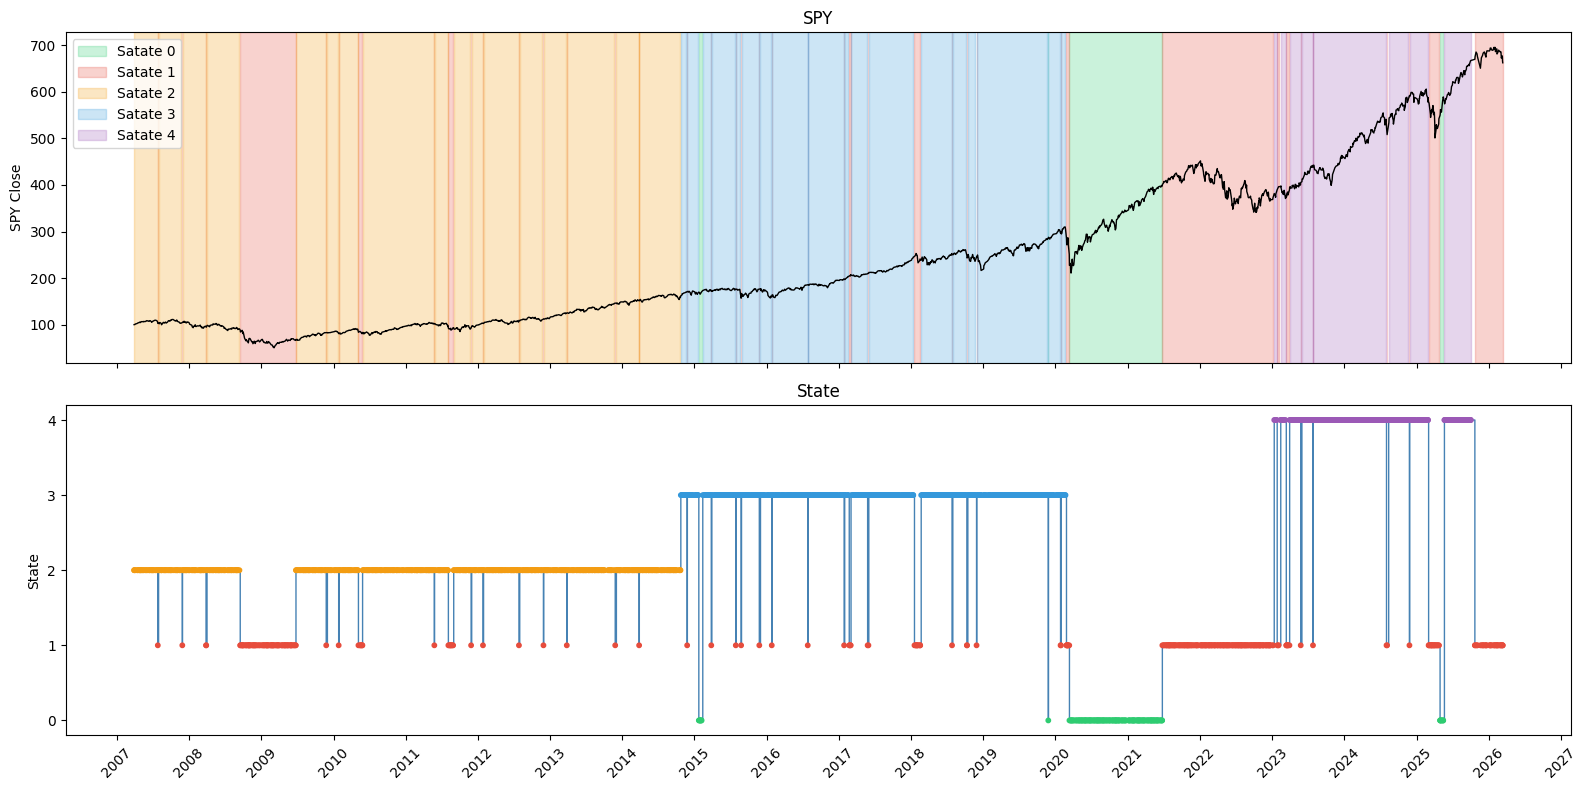

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

n_states = model.n_components
colors = colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#e84393'][:n_states]

# ── SPY price ───────────────────────────────────────────────────────────────
ax1.plot(df.index, df['spy_close'], color='black', lw=1)
ax1.set_ylabel('SPY Close')
ax1.set_title('SPY')

for regime_id, color in enumerate(colors):
    mask = df['state'] == regime_id
    ax1.fill_between(df.index, 0, 1,
                     where=mask, alpha=0.25, color=color,
                     transform=ax1.get_xaxis_transform(),
                     label=f'Satate {regime_id}')
ax1.legend(loc='upper left')

# ── Estate ────────────────────────────────────────────────────────
ax2.plot(df.index, df['state'], color='steelblue', lw=1, drawstyle='steps-post')
ax2.scatter(df.index, df['state'],
            c=[colors[s] for s in df['state']], s=10, zorder=3)
ax2.set_yticks(range(n_states))
ax2.set_ylabel('State')
ax2.set_title('State')

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()